# Testing Code for Optimizers

We will compare SOAP and AdamW

In [50]:
import random
import copy
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import AdamW, Adam

from tqdm import tqdm

from experimental_optimizers.soap_mods import SOAP
from ml_tools import multi_training

Let's generate a simple 1D regression problem

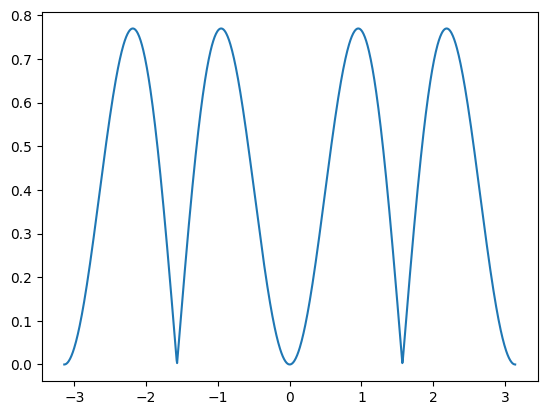

In [51]:
x = np.linspace(-np.pi, np.pi, 1000)
y = np.abs(np.sin(x)*np.sin(2*x))
plt.plot(x, y)

In [52]:
class LinearNN(nn.Module):
    def __init__(self, hidden_size: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32, bias=True),
            nn.ReLU(),
            nn.Linear(32, hidden_size, bias=True),
            nn.ReLU(),
            nn.Linear(hidden_size, 1, bias=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

Create the training and testing datasets, then create a training loop

In [53]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train.reshape(-1, 1))
x_test = scaler.transform(x_test.reshape(-1, 1))

X_train = torch.from_numpy(x_train).float()
Y_train = torch.from_numpy(y_train).float().unsqueeze(1)
X_test = torch.from_numpy(x_test).float()
Y_test = torch.from_numpy(y_test).float().unsqueeze(1)

## Training Functions

Set up of the data loader, loss and optimizers

In [54]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test,  Y_test  = X_test.to(device),  Y_test.to(device)

In [55]:
loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=64, shuffle=True)
criterion = nn.MSELoss()

## Test 1: preconditioning frequency for SOAP without projection

The results should be the same for the two frequencies, as we are not actually updating the preconditioners

In [56]:
optimizer_configs_no_projection = {
    "SOAP_no_projection_100":   lambda p: SOAP(p, lr=0.001, betas = (0.99, 0.999), precondition_1d=True, projection=False, precondition_frequency=100, weight_decay=0.),
    "SOAP_no_projection_10":   lambda p: SOAP(p, lr=0.001, betas = (0.99, 0.999), precondition_1d=True, projection=False, precondition_frequency=10, weight_decay=0.),
}


epochs = 200
training_repetitions = 1

In [57]:
results = multi_training.train_opt(LinearNN, optimizer_configs_no_projection, criterion, loader, training_repetitions, epochs, device, seed_offset=610)

Training with optimizer SOAP_no_projection_100...


Training: 100%|██████████| 200/200 [00:03<00:00, 52.14it/s, mse=0.046570]


Training with optimizer SOAP_no_projection_10...


Training: 100%|██████████| 200/200 [00:03<00:00, 52.71it/s, mse=0.046570]


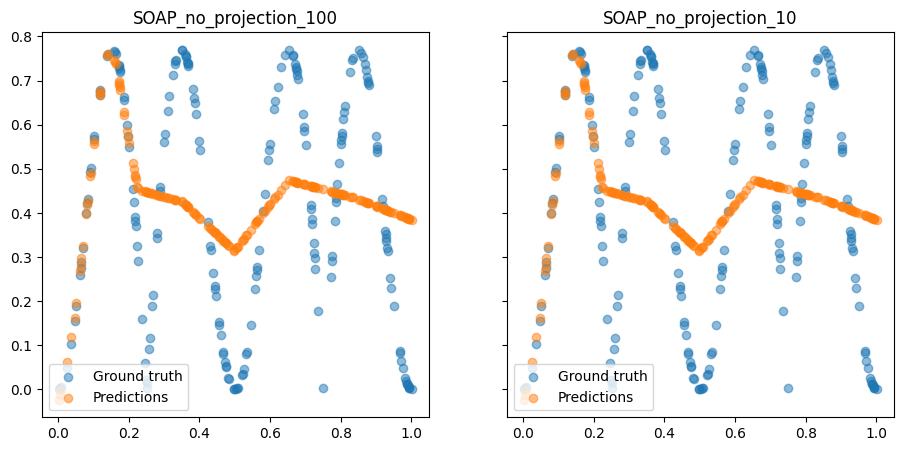

In [58]:
heigth = 5
width = len(optimizer_configs_no_projection) * heigth + 1
fig, axs = plt.subplots(1, len(optimizer_configs_no_projection), figsize=(width, heigth), sharey=True)

for i, opt_name in enumerate(optimizer_configs_no_projection):
    with torch.no_grad():
        mod_to_plot = results[opt_name]["model"]
        mod_to_plot.eval()
        preds = mod_to_plot(X_test).squeeze(1).cpu().detach().numpy()

    axs[i].scatter(x_test, y_test, label="Ground truth", alpha=0.5)
    axs[i].scatter(x_test, preds, label="Predictions", alpha=0.5)
    axs[i].set_title(f"{opt_name}")
    axs[i].legend()

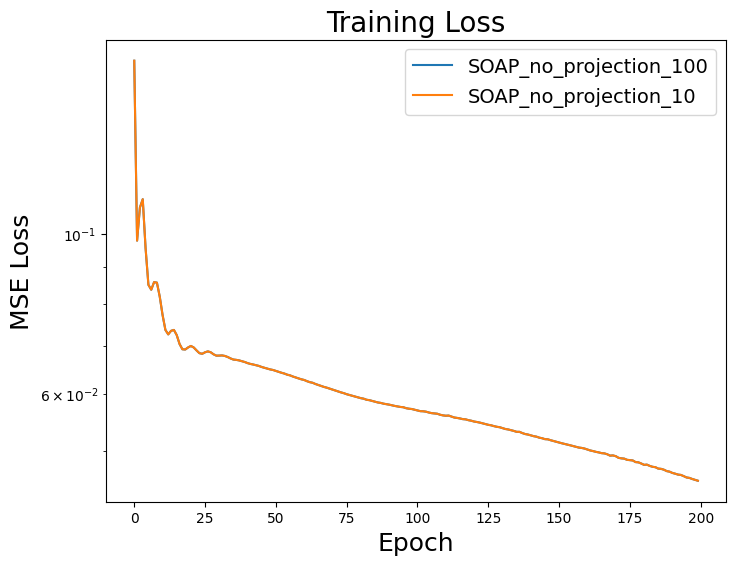

In [59]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, opt_name in enumerate(optimizer_configs_no_projection):
    ax.plot(np.mean(results[opt_name]["loss_histories"], axis = 1), label=opt_name)
    # ax.fill_between(range(epochs),                    
                    # results[opt_name]["loss_history_avg"] - results[opt_name]["loss_history_std"],
                    # results[opt_name]["loss_history_avg"] + results[opt_name]["loss_history_std"], alpha=0.2)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.set
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/SOAP_no_projection.png")

OK

In [60]:
optimizer_configs_proj = {
    "SOAP_with_projection_100":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=True, precondition_frequency=100, weight_decay=0.01),
    "SOAP_with_projection_10":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=True, precondition_frequency=10, weight_decay=0.01),
}


epochs = 200
training_repetitions = 5

In [61]:
results = multi_training.train_opt(LinearNN, optimizer_configs_proj, criterion, loader, training_repetitions, epochs, device,seed_offset=610)

Training with optimizer SOAP_with_projection_100...


Training: 100%|██████████| 200/200 [00:03<00:00, 56.41it/s, mse=0.002606]


Training with optimizer SOAP_with_projection_10...


Training: 100%|██████████| 200/200 [00:03<00:00, 51.16it/s, mse=0.001956]


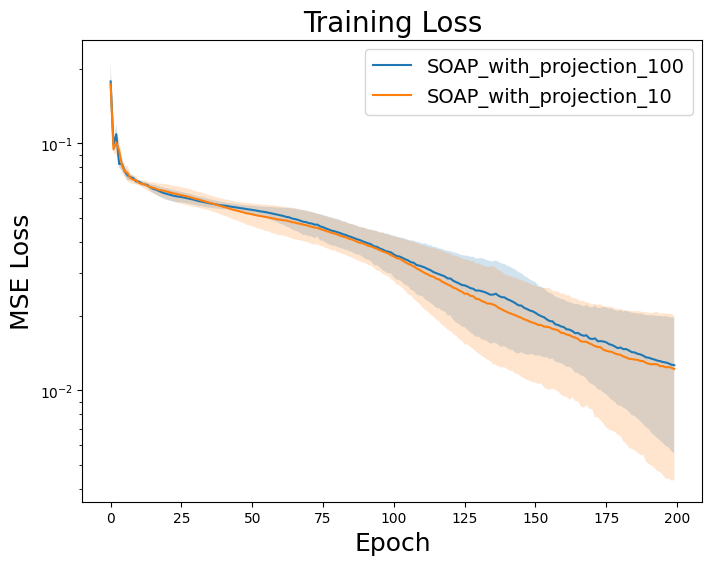

In [62]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, opt_name in enumerate(optimizer_configs_proj):
    loss_avg = np.mean(results[opt_name]["loss_histories"], axis = 1)
    loss_std = np.std(results[opt_name]["loss_histories"], axis = 1)
    ax.plot(loss_avg, label=opt_name)
    ax.fill_between(range(epochs),                    
                    loss_avg - loss_std,
                    loss_avg + loss_std, alpha=0.2)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/soap_preconditioning_frequency.png")

With the projection we see the difference (?)

## Test 1.1: Checking Adam vs Non-Projected SOAP

In [63]:
optimizer_configs = {
    "SOAP_no_projection":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=True, projection=False, precondition_frequency=100, weight_decay=0.0, shampoo_beta=0, normalize_grads=False), # For speed
    "Adam":                 lambda p: Adam(p, lr=0.003, betas = (0.99, 0.999), amsgrad=False)
}
epochs = 100
training_repetitions = 1

In [64]:
loader_total = DataLoader(TensorDataset(X_train, Y_train), batch_size=len(X_train), shuffle=True)

In [65]:
results_total = multi_training.train_opt(LinearNN, optimizer_configs, criterion, loader_total, training_repetitions, epochs, device, seed_offset=610)

Training with optimizer SOAP_no_projection...


Training: 100%|██████████| 100/100 [00:00<00:00, 273.04it/s, mse=0.074018]


Training with optimizer Adam...


Training: 100%|██████████| 100/100 [00:00<00:00, 341.29it/s, mse=0.073483]


In [66]:
results_total["SOAP_no_projection"]["loss_histories"]

array([[0.23568361],
       [0.23568359],
       [0.19050479],
       [0.15514697],
       [0.1285297 ],
       [0.11045113],
       [0.09925596],
       [0.09392956],
       [0.09350479],
       [0.09713434],
       [0.10316021],
       [0.10983051],
       [0.11568438],
       [0.11979871],
       [0.12187893],
       [0.12200402],
       [0.12046021],
       [0.11763135],
       [0.11391695],
       [0.10968813],
       [0.10526662],
       [0.10091612],
       [0.09684283],
       [0.09319483],
       [0.09006672],
       [0.08750907],
       [0.08553583],
       [0.08413173],
       [0.08325253],
       [0.08283326],
       [0.08280165],
       [0.08309497],
       [0.08362614],
       [0.08431234],
       [0.08509075],
       [0.08588873],
       [0.0866643 ],
       [0.08736281],
       [0.08794699],
       [0.08839063],
       [0.08867292],
       [0.08878214],
       [0.08871562],
       [0.0884754 ],
       [0.08806836],
       [0.08750362],
       [0.08679241],
       [0.085

In [67]:
results_total["Adam"]["loss_histories"]

array([[0.23568361],
       [0.19050445],
       [0.15514646],
       [0.12852918],
       [0.11045072],
       [0.0992557 ],
       [0.09392954],
       [0.09350499],
       [0.0971348 ],
       [0.10316081],
       [0.10983112],
       [0.11568489],
       [0.11979904],
       [0.12187904],
       [0.12200394],
       [0.12045993],
       [0.11763092],
       [0.1139164 ],
       [0.10968751],
       [0.105266  ],
       [0.10091548],
       [0.09684225],
       [0.09319433],
       [0.09006627],
       [0.08750866],
       [0.08553546],
       [0.08413139],
       [0.0832522 ],
       [0.08283282],
       [0.08280107],
       [0.08309452],
       [0.08362561],
       [0.08431123],
       [0.08508941],
       [0.08588718],
       [0.08666246],
       [0.08736061],
       [0.08794439],
       [0.0883876 ],
       [0.08866948],
       [0.08877829],
       [0.08871141],
       [0.08847088],
       [0.08806358],
       [0.08749866],
       [0.08678732],
       [0.08594449],
       [0.084

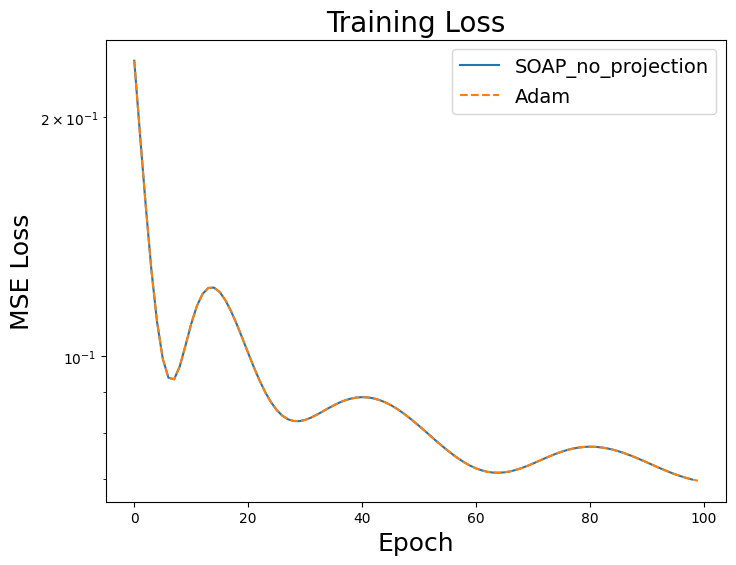

In [68]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, opt_name in enumerate(optimizer_configs):
    loss_avg = np.mean(results_total[opt_name]["loss_histories"], axis = 1)
    loss_std = np.std(results_total[opt_name]["loss_histories"], axis = 1)
    if opt_name == "Adam":
        ax.plot(loss_avg, label=opt_name, linestyle="--")
    elif opt_name == "SOAP_no_projection":
        ax.plot(loss_avg[1:], label=opt_name)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/soap2adam.png")

In [69]:
results_total["SOAP_no_projection"]["opt_state"]

{'state': {0: {'step': 99,
   'exp_avg': tensor([[ 0.0000],
           [ 0.0000],
           [-0.0037],
           [ 0.0000],
           [ 0.0006],
           [ 0.0000],
           [ 0.0004],
           [ 0.0009],
           [ 0.0004],
           [ 0.0000],
           [ 0.0000],
           [ 0.0013],
           [ 0.0000],
           [ 0.0016],
           [ 0.0000],
           [ 0.0000],
           [ 0.0000],
           [ 0.0045],
           [ 0.0049],
           [ 0.0018],
           [ 0.0000],
           [ 0.0044],
           [ 0.0000],
           [ 0.0040],
           [ 0.0022],
           [ 0.0000],
           [ 0.0000],
           [ 0.0000],
           [ 0.0012],
           [ 0.0029],
           [ 0.0000],
           [ 0.0000]], device='cuda:0'),
   'exp_avg_sq': tensor([[0.0000e+00],
           [0.0000e+00],
           [2.3342e-05],
           [0.0000e+00],
           [1.3709e-05],
           [0.0000e+00],
           [7.1804e-06],
           [2.2534e-06],
           [6.6593e-07],


In [70]:
results_total["Adam"]["opt_state"]

{'state': {0: {'step': tensor(100.),
   'exp_avg': tensor([[ 0.0000],
           [ 0.0000],
           [-0.0038],
           [ 0.0000],
           [ 0.0006],
           [ 0.0000],
           [ 0.0004],
           [ 0.0009],
           [ 0.0004],
           [ 0.0000],
           [ 0.0000],
           [ 0.0013],
           [ 0.0000],
           [ 0.0016],
           [ 0.0000],
           [ 0.0000],
           [ 0.0000],
           [ 0.0045],
           [ 0.0049],
           [ 0.0018],
           [ 0.0000],
           [ 0.0043],
           [ 0.0000],
           [ 0.0040],
           [ 0.0022],
           [ 0.0000],
           [ 0.0000],
           [ 0.0000],
           [ 0.0012],
           [ 0.0029],
           [ 0.0000],
           [ 0.0000]], device='cuda:0'),
   'exp_avg_sq': tensor([[0.0000e+00],
           [0.0000e+00],
           [2.3343e-05],
           [0.0000e+00],
           [1.3695e-05],
           [0.0000e+00],
           [7.1758e-06],
           [2.2512e-06],
           [6.6

Ok, I still need to understand why the first two loss values are equal for soap... Initialization?

## Test 2: Testing with different algorithms

In principle, the non-projected should show similar results to AdamW

In [71]:
optimizer_configs = {
    "SOAP_no_projection":   lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=False, projection=False, precondition_frequency=100, weight_decay=0.0, shampoo_beta=0, normalize_grads=False), # For speed
    "SOAP_with_projection": lambda p: SOAP(p, lr=0.003, betas = (0.99, 0.999), precondition_1d=False, projection=True, precondition_frequency=10, weight_decay=0.0),
    "Adam":                 lambda p: Adam(p, lr=0.003, betas = (0.99, 0.999), amsgrad=False)
}
epochs = 200
training_repetitions = 25

In [72]:
results = multi_training.train_opt(LinearNN, optimizer_configs, criterion, loader, training_repetitions, epochs, device, seed_offset=610)

Training with optimizer SOAP_no_projection...


Training:   0%|          | 0/200 [00:00<?, ?it/s, mse=0.134860]

Training: 100%|██████████| 200/200 [00:03<00:00, 60.98it/s, mse=0.029861]


Training with optimizer SOAP_with_projection...


Training: 100%|██████████| 200/200 [00:03<00:00, 60.71it/s, mse=0.015974]


Training with optimizer Adam...


Training: 100%|██████████| 200/200 [00:01<00:00, 136.62it/s, mse=0.037980]


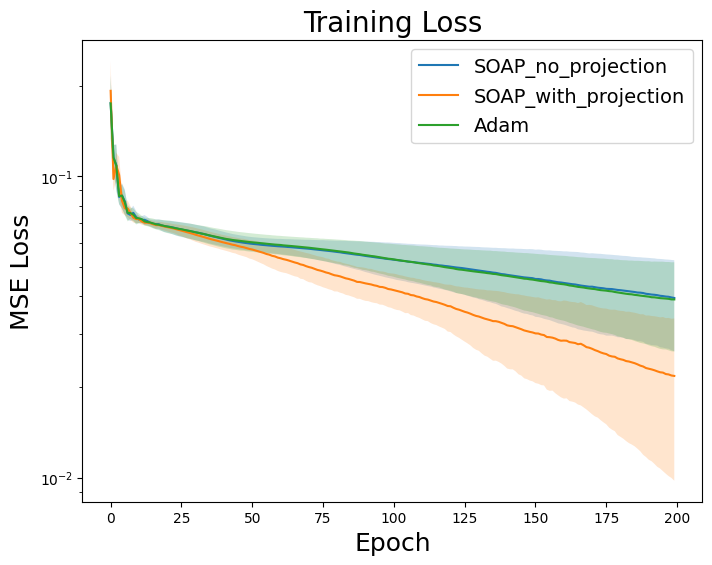

In [73]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
for i, opt_name in enumerate(optimizer_configs):
    loss_avg = np.mean(results[opt_name]["loss_histories"], axis = 1)
    loss_std = np.std(results[opt_name]["loss_histories"], axis = 1)
    ax.plot(loss_avg, label=opt_name)
    ax.fill_between(range(epochs),                    
                    loss_avg - loss_std,
                    loss_avg + loss_std, alpha=0.2)
ax.set_title("Training Loss", fontsize=20)
ax.set_yscale("log")
ax.set_xlabel("Epoch", fontsize=18)
ax.set_ylabel("MSE Loss", fontsize=18)
ax.legend(fontsize=14)

plt.savefig("./outputs/plots/three_algos.png")

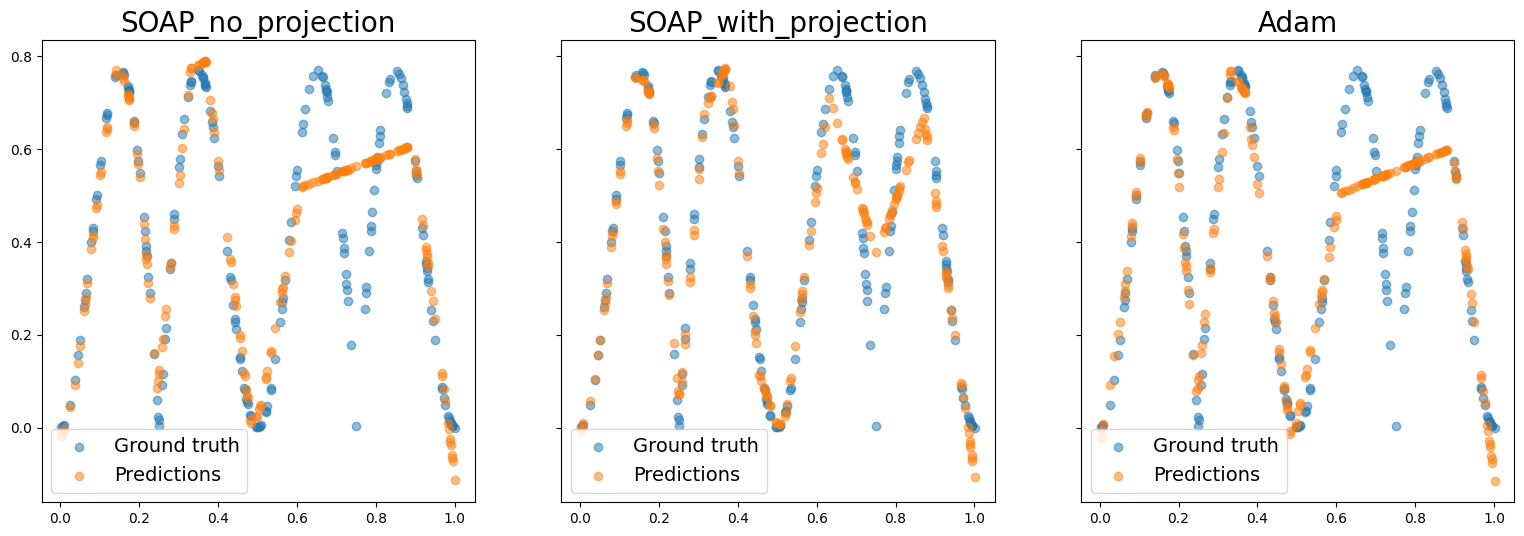

In [74]:
heigth = 6
width = len(optimizer_configs) * heigth + 1
fig, axs = plt.subplots(1, len(optimizer_configs), figsize=(width, heigth), sharey=True)

for i, opt_name in enumerate(optimizer_configs):
    with torch.no_grad():
        mod_to_plot = results[opt_name]["model"]
        mod_to_plot.eval()
        preds = mod_to_plot(X_test).squeeze(1).cpu().detach().numpy()

    axs[i].scatter(x_test, y_test, label="Ground truth", alpha=0.5)
    axs[i].scatter(x_test, preds, label="Predictions", alpha=0.5)
    axs[i].set_title(f"{opt_name}", fontsize=20)
    axs[i].legend(fontsize=14, loc="lower left")
plt.savefig("./outputs/plots/three_algos_preds.png")

In [ ]:
results.keys()

In [ ]:
results["Adam"]["opt_state"]["param_groups"]

In [ ]:
results["SOAP_no_projection"]["opt_state"]["param_groups"]